In [2]:
# =========================================================
# Beginner-Friendly Python Script: Iris Dataset Analysis
# Works in Google Colab
# =========================================================

# 1. Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional but nice) Improve plot appearance
sns.set(style="whitegrid")

In [3]:

# ---------------------------------------------------------
# 2. Load the Iris dataset
# ---------------------------------------------------------
# Seaborn has the Iris dataset built in, so no file download needed
iris = sns.load_dataset("iris")

# Display the first few rows
print("First 5 rows of the dataset:")
print(iris.head())

# ---------------------------------------------------------
# 3. Basic Summary statistics for the whole dataset
# ---------------------------------------------------------
print("\nSummary statistics for the entire dataset:")
print(iris.describe())

# ---------------------------------------------------------
# 4. Basic Summary statistics grouped by species
# ---------------------------------------------------------
print("\nSummary statistics grouped by species:")
grouped_stats = iris.groupby("species").describe()
print(grouped_stats)

First 5 rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Summary statistics for the entire dataset:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Su

In [8]:

# ---------------------------------------------------------
# 5. EXTENDED Summary statistics (custom)
# ---------------------------------------------------------
# Select numeric columns only
numeric_cols = iris.select_dtypes(include="number")

# Create a summary statistics table
summary_stats = pd.DataFrame({
    "Mean": numeric_cols.mean(),
    "Median": numeric_cols.median(),
    "Mode": numeric_cols.mode().iloc[0],   # first mode
    "Min": numeric_cols.min(),
    "Max": numeric_cols.max(),
    "Range": numeric_cols.max() - numeric_cols.min(),
    "Std Dev": numeric_cols.std(),
    "Skewness": numeric_cols.skew(),
    "Kurtosis": numeric_cols.kurt()
})

print("\nExtended Summary Statistics (Entire Dataset):")
print(summary_stats)




Extended Summary Statistics (Entire Dataset):
                  Mean  Median  Mode  Min  Max  Range   Std Dev  Skewness  \
sepal_length  5.843333    5.80   5.0  4.3  7.9    3.6  0.828066  0.314911   
sepal_width   3.057333    3.00   3.0  2.0  4.4    2.4  0.435866  0.318966   
petal_length  3.758000    4.35   1.4  1.0  6.9    5.9  1.765298 -0.274884   
petal_width   1.199333    1.30   0.2  0.1  2.5    2.4  0.762238 -0.102967   

              Kurtosis  
sepal_length -0.552064  
sepal_width   0.228249  
petal_length -1.402103  
petal_width  -1.340604  


In [11]:
# ---------------------------------------------------------
# 6. EXTENDED Summary statistics grouped by species
# ---------------------------------------------------------
grouped_stats = iris.groupby("species").agg(
    Mean=("sepal_length", "mean"),
    Median=("sepal_length", "median"),
    Min=("sepal_length", "min"),
    Max=("sepal_length", "max"),
    Std_Dev=("sepal_length", "std"),
    Skewness=("sepal_length", pd.Series.skew),
    Kurtosis=("sepal_length", pd.Series.kurt)
)

print("\nExtended Summary Statistics by Species (Sepal Length shown):")
print(grouped_stats)


Extended Summary Statistics by Species (Sepal Length shown):
             Mean  Median  Min  Max   Std_Dev  Skewness  Kurtosis
species                                                          
setosa      5.006     5.0  4.3  5.8  0.352490  0.120087 -0.252689
versicolor  5.936     5.9  4.9  7.0  0.516171  0.105378 -0.533010
virginica   6.588     6.5  4.9  7.9  0.635880  0.118015  0.032904


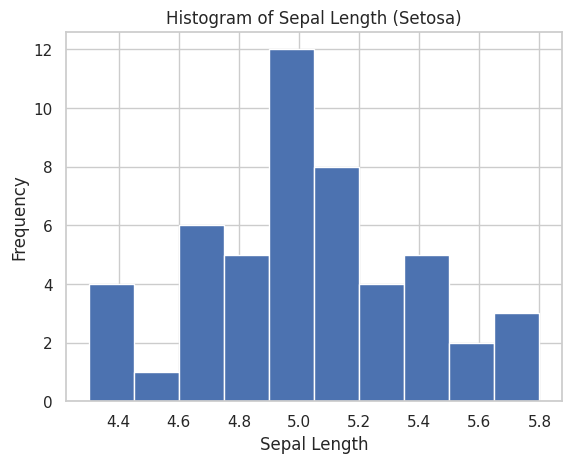

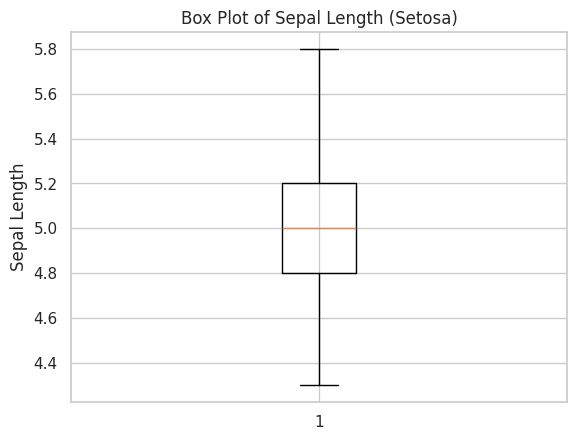

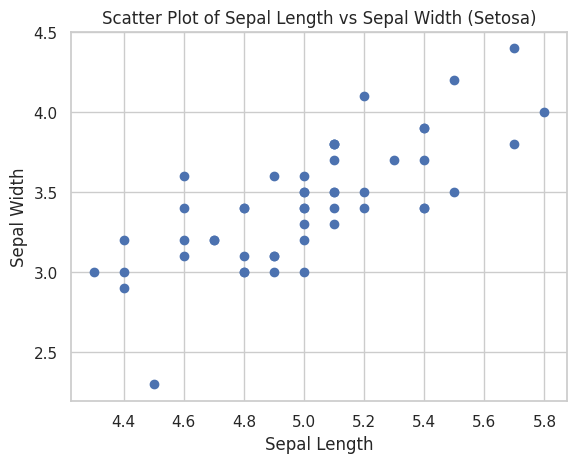

In [15]:


# ---------------------------------------------------------
# 7. Filter data for Setosa species only
# ---------------------------------------------------------
setosa = iris[iris["species"] == "setosa"]

# ---------------------------------------------------------
# 8. Histogram of Sepal Length for Setosa
# ---------------------------------------------------------
plt.figure()
plt.hist(setosa["sepal_length"], bins=10)
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.title("Histogram of Sepal Length (Setosa)")
plt.show()

# ---------------------------------------------------------
# 9. Box plot of Sepal Length for Setosa
# ---------------------------------------------------------
plt.figure()
plt.boxplot(setosa["sepal_length"])
plt.ylabel("Sepal Length")
plt.title("Box Plot of Sepal Length (Setosa)")
plt.show()

# ---------------------------------------------------------
# 10. Scatter Plot: Sepal Length vs Sepal Width (Setosa)
# ---------------------------------------------------------
plt.figure()
plt.scatter(
    setosa["sepal_length"],
    setosa["sepal_width"]
)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Scatter Plot of Sepal Length vs Sepal Width (Setosa)")
plt.show()



In [14]:
# ---------------------------------------------------------
# 11. Pearson Correlation between Sepal Length and Sepal Width (Setosa)
# ---------------------------------------------------------
correlation = setosa["sepal_length"].corr(setosa["sepal_width"], method="pearson")

print("\nPearson Correlation (Setosa):")
print("Sepal Length vs Sepal Width =", correlation)



Pearson Correlation (Setosa):
Sepal Length vs Sepal Width = 0.7425466856651597
